0mM TEMPO: B = 0.1131 * I^0.6038  (R^2 = 0.9993)
1mM TEMPO: B = 0.0928 * I^0.6336  (R^2 = 0.9953)
3mM TEMPO: B = 0.0717 * I^0.6669  (R^2 = 0.9837)
5mM TEMPO: B = 0.0529 * I^0.6969  (R^2 = 0.9984)


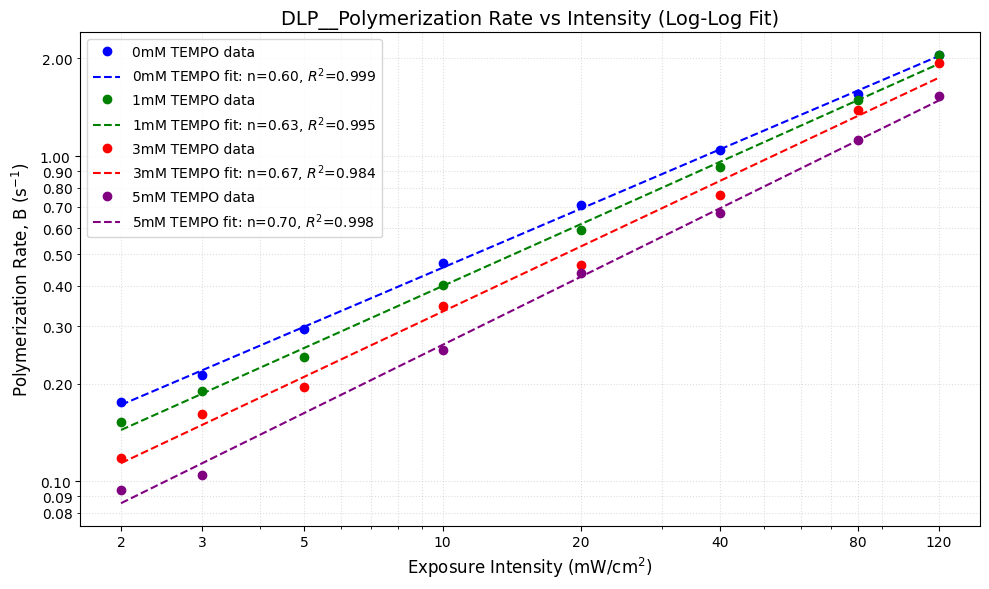

0mM TEMPO: inhibition time C= 7.8714 * I^-0.6204  (R^2 = 0.9601)
1mM TEMPO: inhibition time C= 27.5566 * I^-0.7717  (R^2 = 0.9984)
3mM TEMPO: inhibition time C= 55.4535 * I^-0.8777  (R^2 = 0.9754)
5mM TEMPO: inhibition time C= 87.5993 * I^-0.9387  (R^2 = 0.9892)


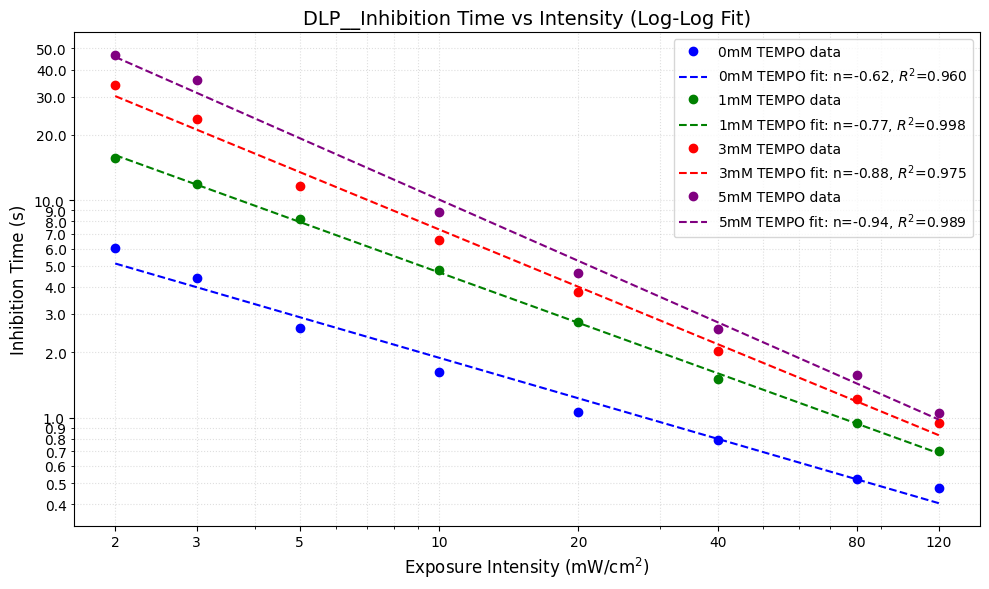

0mM TEMPO: inhibition energy = 12.6124
1mM TEMPO: inhibition energy = 34.0231
3mM TEMPO: inhibition energy = 67.9730
5mM TEMPO: inhibition energy = 97.4406


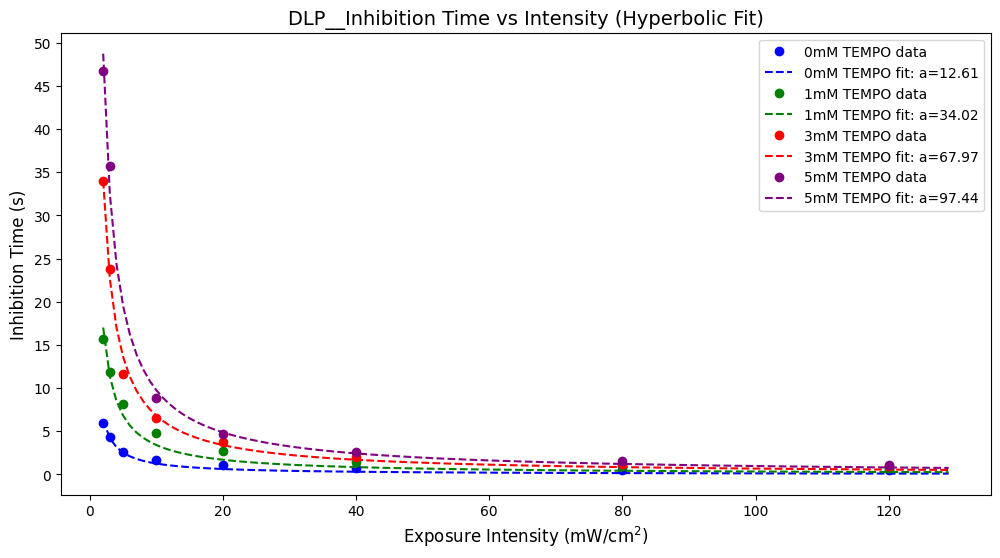

In [3]:
#Zak asked for New data from Jack 26/10/01  ON DLP SYSTEM
# 0/1/3/5mMol TEMPO 2,3,5,10,20,40,80,120mW/cm2
#Log-log (power-law) fit of polymerization rate B (and Inhibition Time)vs excitation intensity, analogous to Figure 2C in
#O'Dea, Scruggs, Page, Adv. Funct. Mater. 2026, 36, e30758 (rp ~ I^n; Type I slope=0.64, Type II slope=0.53)
#https://advanced.onlinelibrary.wiley.com/doi/epdf/10.1002/adfm.202530758 Reference sources
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, ScalarFormatter,FixedLocator, FuncFormatter
from scipy.optimize import curve_fit

#ax = plt.gca()

datasets = {
    '0mM TEMPO': {
        'intensity': np.array([2,3,5,10,20,40,80,120], dtype=float),
        'rate': np.array([0.1749,0.2125,0.2941,0.4681,0.7084,1.0427,1.5550,2.0534]),
        'inhibition_time': np.array([6.0040,4.3897,2.5824,1.6241,1.0592,0.7916,0.5221,0.4735]),
        'color': 'blue',
    },
    '1mM TEMPO': {
       'intensity': np.array([2,3,5,10,20,40,80,120], dtype=float),
       'rate': np.array([0.1524,0.1901,0.2409,0.4008,0.5919,0.9288,1.4925,2.0436]),
       'inhibition_time': np.array([15.6413,11.9095,8.2077,4.7707,2.7418,1.4989,0.9454,0.6987]),
       'color': 'green',
    },
    '3mM TEMPO': {
           'intensity': np.array([2,3,5,10,20,40,80,120], dtype=float),
           'rate': np.array([0.1184,0.1611,0.1957,0.3476,0.4617,0.7605,1.3879,1.9343]),
           'inhibition_time': np.array([34.0117,23.7427,11.6693,6.5537,3.7861,2.0193,1.2204,0.9406]),
           'color': 'red',
    },
    '5mM TEMPO': {
        'intensity': np.array([2,3,10,20,40,80,120], dtype=float),
        'rate': np.array([0.0938,0.1049,0.2541,0.4381,0.6674,1.1231,1.5313]),
        'inhibition_time': np.array([46.7662,35.6787,8.8780,4.6295,2.5611,1.5767,1.0540]),
        'color': 'purple',
    },
}

plt.figure(figsize=(10, 6))
ax = plt.gca()
for label, d in datasets.items():
    I, b, color = d['intensity'], d['rate'], d['color']
    log_I, log_b = np.log10(I), np.log10(b)

    n_fit, log_k = np.polyfit(log_I, log_b, 1)
    b_fit = 10**log_k * I**n_fit
    r2 = 1 - np.sum((b - b_fit)**2) / np.sum((b - np.mean(b))**2)

    plt.loglog(I, b, 'o', color=color, label=f'{label} data')
    I_smooth = np.logspace(np.log10(I.min()), np.log10(I.max()), 50)
    
    plt.loglog(I_smooth, 10**log_k * I_smooth**n_fit, '--', color=color,
               label=f'{label} fit: n={n_fit:.2f}, $R^2$={r2:.3f}')

    print(f'{label}: B = {10**log_k:.4f} * I^{n_fit:.4f}  (R^2 = {r2:.4f})')

plt.xlabel('Exposure Intensity (mW/cm$^2$)',fontsize=12)
plt.ylabel('Polymerization Rate, B (s$^{-1}$)',fontsize=12)
plt.title("DLP__Polymerization Rate vs Intensity (Log-Log Fit)",fontsize=14)
# --- finer ticks ---
ax.xaxis.set_minor_locator(LogLocator(subs=np.arange(2, 10) * 0.1))
ax.xaxis.set_major_locator(FixedLocator([2, 3, 5, 10, 20, 40, 80, 120]))
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x:g}'))
ax.yaxis.set_minor_locator(LogLocator(subs=np.arange(2, 10) * 0.1))
ax.yaxis.set_minor_formatter(ScalarFormatter())
ax.yaxis.set_major_formatter(ScalarFormatter())
plt.legend()
plt.grid(True, which='both', ls=':', alpha=0.4)
plt.tight_layout()
plt.show()

# Log-log (power-law) fit of inhibition time vs excitation intensity

plt.figure(figsize=(10, 6))
ax = plt.gca()
for label, d in datasets.items():
    intensity = d['intensity']
    inhibition_time = d['inhibition_time']
    color = d['color']
    log_intensity, log_time = np.log10(intensity), np.log10(inhibition_time)

    slope, log_k = np.polyfit(log_intensity, log_time, 1)
    time_fit = 10**log_k * intensity**slope
    r2 = 1 - np.sum((inhibition_time - time_fit)**2) / np.sum((inhibition_time - np.mean(inhibition_time))**2)

    plt.loglog(intensity, inhibition_time, 'o', color=color, label=f'{label} data')
    intensity_smooth = np.logspace(np.log10(intensity.min()), np.log10(intensity.max()), 50)
    fit_values = 10**log_k * intensity_smooth**slope
    plt.loglog(intensity_smooth, fit_values, '--', color=color,
               label=f'{label} fit: n={slope:.2f}, $R^2$={r2:.3f}')

    # annotation_x = intensity_smooth[int(0.72 * len(intensity_smooth))]
    # annotation_y = 10**log_k * annotation_x**slope
    # ax.annotate(f'slope = {slope:.2f}', (annotation_x, annotation_y),
    #             color=color, fontsize=12, ha='right', va='bottom',
    #             xytext=(-50, -10), textcoords='offset points')

    print(f'{label}: inhibition time C= {10**log_k:.4f} * I^{slope:.4f}  (R^2 = {r2:.4f})')

plt.xlabel('Exposure Intensity (mW/cm$^2$)', fontsize=12)
plt.ylabel('Inhibition Time (s)', fontsize=12)
plt.title('DLP__Inhibition Time vs Intensity (Log-Log Fit)', fontsize=14)
ax.xaxis.set_minor_locator(LogLocator(subs=np.arange(2, 10) * 0.1))
ax.xaxis.set_major_locator(FixedLocator([2, 3, 5, 10, 20, 40, 80, 120]))
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x:g}'))
ax.yaxis.set_minor_locator(LogLocator(subs=np.arange(2, 10) * 0.1))
ax.yaxis.set_minor_formatter(ScalarFormatter())
ax.yaxis.set_major_formatter(ScalarFormatter())
plt.legend()
plt.grid(True, which='both', ls=':', alpha=0.4)
plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 6))
ax = plt.gca()
def hyperbolic_model(x, a):
    return a / x

#plt.figure(figsize=(10, 6))
ax = plt.gca()
for label, d in datasets.items():
    intensity = d['intensity']
    inhibition_time = d['inhibition_time']
    color = d['color']
    plt.plot(intensity, inhibition_time, 'o', color=color, label=f'{label} data')
    popt, pcov = curve_fit(hyperbolic_model, intensity, inhibition_time)

    a_fit = popt[0]
    print(f'{label}: inhibition energy = {a_fit:.4f}')
    fit_values = hyperbolic_model(np.arange(2,130,1), a_fit)
    plt.plot(np.arange(2,130,1), fit_values, '--', color=color,
             label=f'{label} fit: a={a_fit:.2f}')
    plt.legend()
    plt.xlabel('Exposure Intensity (mW/cm$^2$)', fontsize=12)
    plt.ylabel('Inhibition Time (s)', fontsize=12)
    plt.title('DLP__Inhibition Time vs Intensity (Hyperbolic Fit)',fontsize=14)
    plt.yticks(np.arange(0,55,5))





In [ ]:
#This is for 0mM TEMPO (Jack Shared on 26/09/01)
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

#TEMPO_0mM_a=[0.9730,0.9528,0.9581]
TEMPO_0mM_b=[0.8707,1.0447,1.1906,1.3293,1.5562,1.9823]
TEMPO_0mM_c=[1.0273,0.8405,0.6985,0.6144,0.5320,0.3726]
TMEPO_0mM_intensity=[30,40,50,60,80,120]


slope,inter=np.polyfit(TMEPO_0mM_intensity,TEMPO_0mM_b,1)
print(f"Slope: {slope:.4f}, Intercept: {inter:.4f}")
b_fit = slope*np.array(TMEPO_0mM_intensity) + inter
r2_lin = 1 - np.sum((np.array(TEMPO_0mM_b) - b_fit)**2) / np.sum((np.array(TEMPO_0mM_b) - np.mean(TEMPO_0mM_b))**2)
print(f"Linear fit R^2: {r2_lin:.4f}")
print(f'Fitted inhibition time(s): {np.array(TEMPO_0mM_c)}')
print(f'Fitted inhibition energy(mJ/cm2): {np.array(TEMPO_0mM_c)*np.array(TMEPO_0mM_intensity)}')
print(f'Average Inhibition Energy(mJ/cm2): {np.average(np.array(TEMPO_0mM_c)*np.array(TMEPO_0mM_intensity)):.4f}')

plt.scatter(TMEPO_0mM_intensity,TEMPO_0mM_b, label='Data Points')
plt.plot(TMEPO_0mM_intensity, slope*np.array(TMEPO_0mM_intensity) + inter, 
         linestyle='--', label=f'Linear Fit: y = {slope:.4f}x + {inter:.4}, $R^2$ = {r2_lin:.4f}')
plt.xlabel('Intensity')
plt.ylabel('b')
plt.title('Absorption vs Intensity_0mM TEMPO')
plt.legend()
plt.show()

def fit_func(x,a):
    return a/x
popt, pcov = curve_fit(fit_func, TMEPO_0mM_intensity, TEMPO_0mM_c)
a_err = np.sqrt(np.diag(pcov))[0]
c_fit = fit_func(np.array(TMEPO_0mM_intensity), popt[0])
rmse_curve = np.sqrt(np.mean((np.array(TEMPO_0mM_c) - c_fit)**2))
print(f"Fitted parameter a: {popt[0]:.4f} ± {a_err:.4f}")
print(f"Curve fit RMSE: {rmse_curve:.4f}")

plt.figure()
plt.scatter(TMEPO_0mM_intensity,TEMPO_0mM_c, label='Data Points')
plt.plot(TMEPO_0mM_intensity, fit_func(TMEPO_0mM_intensity, popt[0]), 'r--', label=f'Fit: y = a/x, $a$ = {popt[0]:.3f} ± {a_err:.3f}, RMSE = {rmse_curve:.3f}')
plt.title('Fitted Inhibition Time_0mM TEMPO')
plt.xlabel('Intensity')
plt.ylabel('Inhibition Time')
plt.legend()
plt.show()

In [ ]:
#This is for 5mM TEMPO (Jack Shared on 26/09/01)
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

#TEMPO_0mM_a=[0.9730,0.9528,0.9581]
TEMPO_0mM_b=[0.5625,0.6443,0.7798,0.9445,1.2024,1.3228,1.5049]
TEMPO_0mM_c=[3.8170,2.6200,2.4345,2.0319,1.6434,1.3730,1.0482]
TMEPO_0mM_intensity=[30,40,50,60,80,100,120]


slope,inter=np.polyfit(TMEPO_0mM_intensity,TEMPO_0mM_b,1)
print(f"Slope: {slope:.4f}, Intercept: {inter:.4f}")
b_fit = slope*np.array(TMEPO_0mM_intensity) + inter
r2_lin = 1 - np.sum((np.array(TEMPO_0mM_b) - b_fit)**2) / np.sum((np.array(TEMPO_0mM_b) - np.mean(TEMPO_0mM_b))**2)
print(f"Linear fit R^2: {r2_lin:.4f}")
print(f'Fitted inhibition time(s): {np.array(TEMPO_0mM_c)}')
print(f'Fitted inhibition energy(mJ/cm2): {np.array(TEMPO_0mM_c)*np.array(TMEPO_0mM_intensity)}')
print(f'Average Inhibition Energy(mJ/cm2): {np.average(np.array(TEMPO_0mM_c)*np.array(TMEPO_0mM_intensity)):.4f}')

plt.scatter(TMEPO_0mM_intensity,TEMPO_0mM_b, label='Data Points')
plt.plot(TMEPO_0mM_intensity, slope*np.array(TMEPO_0mM_intensity) + inter, 
         linestyle='--', label=f'Linear Fit: y = {slope:.4f}x + {inter:.4}, $R^2$ = {r2_lin:.4f}')
plt.xlabel('Intensity')
plt.ylabel('b')
plt.title('Absorption vs Intensity_5mM TEMPO')
plt.legend()
plt.show()

def fit_func(x,a):
    return a/x
popt, pcov = curve_fit(fit_func, TMEPO_0mM_intensity, TEMPO_0mM_c)
a_err = np.sqrt(np.diag(pcov))[0]
c_fit = fit_func(np.array(TMEPO_0mM_intensity), popt[0])
rmse_curve = np.sqrt(np.mean((np.array(TEMPO_0mM_c) - c_fit)**2))
print(f"Fitted parameter a: {popt[0]:.4f} ± {a_err:.4f}")
print(f"Curve fit RMSE: {rmse_curve:.4f}")

plt.figure()
plt.scatter(TMEPO_0mM_intensity,TEMPO_0mM_c, label='Data Points')
plt.plot(TMEPO_0mM_intensity, fit_func(TMEPO_0mM_intensity, popt[0]), 'r--', label=f'Fit: y = a/x, $a$ = {popt[0]:.3f} ± {a_err:.3f}, RMSE = {rmse_curve:.3f}')
plt.title('Fitted Inhibition Time_5mM TEMPO')
plt.xlabel('Intensity')
plt.ylabel('Inhibition Time')
plt.legend()
plt.show()

,concentration,intensity_mw,rate_mean,rate_std,inhibition_time_mean,inhibition_time_std,r_squared_min,n_replicates,n_rate_replicates,n_inhibition_replicates,n_total,n_rejected
0,0mM TEMPO,2.0,0.1730,0.0077,6.1035,0.1574,0.9969,3,3,3,3,0
1,0mM TEMPO,3.0,0.2174,0.0156,4.3940,0.0517,0.9976,3,3,3,3,0
2,0mM TEMPO,5.0,0.2939,0.0039,2.9608,0.6377,0.9982,4,4,4,4,0
3,0mM TEMPO,10.0,0.4645,0.0051,1.6367,0.0178,0.9977,2,2,2,3,1
4,0mM TEMPO,20.0,0.7133,0.0069,1.0031,0.0793,0.9971,2,2,2,3,1
5,0mM TEMPO,40.0,1.0267,0.0153,0.7782,0.0525,0.9949,3,3,3,3,0
6,0mM TEMPO,80.0,1.5283,0.0117,0.5124,0.1314,0.9939,3,3,3,3,0
7,0mM TEMPO,120.0,2.0096,0.0620,0.4735,NaN,0.9888,2,2,1,3,1
8,1mM TEMPO,2.0,0.1524,0.0046,15.6413,0.2987,0.9974,3,3,3,3,0
9,1mM TEMPO,3.0,0.1901,0.0010,11.9095,0.0939,0.9974,3,3,3,3,0


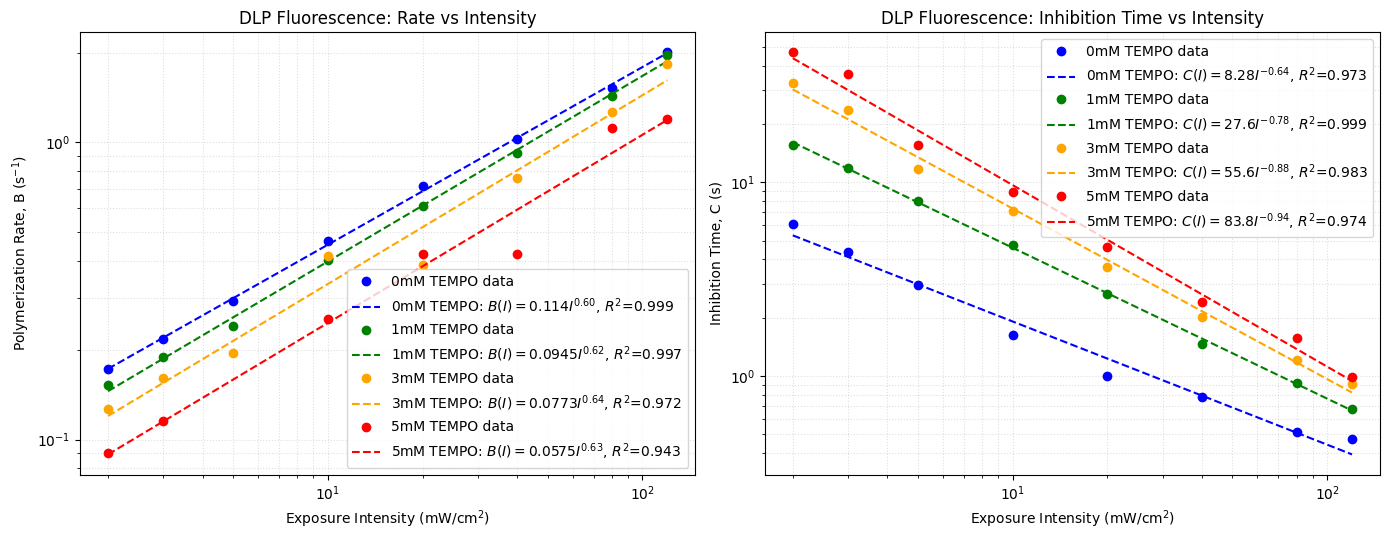

In [1]:
# 2026-10-01 DLP fluorescence-only rate and inhibition-time analysis
# Uses new variable names so the original datasets above remain unchanged.
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from kinetic_analysis import analyze_dlp_fluorescence, build_kinetic_datasets

DLP_FLUO_ROOT_20261001 = Path(r'.\PastDataFiles\20261001\DLP_Fluo\data\conditions')
dlp_fluo_trial_fits_20261001, dlp_fluo_summary_20261001 = (
    analyze_dlp_fluorescence(DLP_FLUO_ROOT_20261001)
)
DLP_Fluo_datasets_20261001 = build_kinetic_datasets(dlp_fluo_summary_20261001)
display(dlp_fluo_summary_20261001.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for label, data in DLP_Fluo_datasets_20261001.items():
    intensity = data['intensity']
    series = [
        (axes[0], 'B', data['polymerization_rate'], data['B_K'], data['B_N'], 'Polymerization Rate, B (s$^{-1}$)'),
        (axes[1], 'C', data['inhibition_time'], data['C_K'], data['C_N'], 'Inhibition Time, C (s)'),
    ]
    for axis, symbol, values, coefficient, exponent, ylabel in series:
        usable = np.isfinite(values) & (values > 0)
        used_intensity, used_values = intensity[usable], values[usable]
        predicted = coefficient * used_intensity**exponent
        r_squared = 1 - np.sum((used_values - predicted)**2) / np.sum((used_values - used_values.mean())**2)
        smooth_intensity = np.logspace(np.log10(used_intensity.min()), np.log10(used_intensity.max()), 100)
        axis.loglog(used_intensity, used_values, 'o', color=data['color'], label=f'{label} data')
        fit_label = (f'{label}: ${symbol}(I)={coefficient:.3g}'
                     f'I^{{{exponent:.2f}}}$, $R^2$={r_squared:.3f}')
        axis.loglog(smooth_intensity, coefficient * smooth_intensity**exponent, '--',
                    color=data['color'], label=fit_label)
        axis.set_xlabel('Exposure Intensity (mW/cm$^2$)')
        axis.set_ylabel(ylabel)
        axis.grid(True, which='both', ls=':', alpha=0.4)
for axis in axes:
    axis.legend()
axes[0].set_title('DLP Fluorescence: Rate vs Intensity')
axes[1].set_title('DLP Fluorescence: Inhibition Time vs Intensity')
fig.tight_layout()
plt.show()
